In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import XLMRobertaTokenizer
!pip install emoji
import emoji

In [2]:
# Bengali datasets are often saved as utf-8-sig
train_df = pd.read_csv("train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("validation.csv", encoding="utf-8-sig")
test_df  = pd.read_csv("test.csv", encoding="utf-8-sig")

Datasets **shapes**

In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(110645, 9)
(15806, 9)
(31614, 9)


Dataset **Columns**

In [ ]:
train_df.columns
train_df.info()
train_df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110645 entries, 0 to 110644
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           110645 non-null  int64 
 1   Book_Name    110645 non-null  object
 2   Writer_Name  110456 non-null  object
 3   Category     110615 non-null  object
 4   Rating       110645 non-null  int64 
 5   Review       110645 non-null  object
 6   Site         110645 non-null  object
 7   sentiment    110645 non-null  object
 8   label        110645 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 7.6+ MB


,0
id,int64
Book_Name,object
Writer_Name,object
Category,object
Rating,int64
Review,object
Site,object
sentiment,object
label,int64


In [ ]:
val_df.columns
val_df.info()
val_df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15806 entries, 0 to 15805
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15806 non-null  int64 
 1   Book_Name    15806 non-null  object
 2   Writer_Name  15785 non-null  object
 3   Category     15804 non-null  object
 4   Rating       15806 non-null  int64 
 5   Review       15806 non-null  object
 6   Site         15806 non-null  object
 7   sentiment    15806 non-null  object
 8   label        15806 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 1.1+ MB


,0
id,int64
Book_Name,object
Writer_Name,object
Category,object
Rating,int64
Review,object
Site,object
sentiment,object
label,int64


In [ ]:
test_df.columns
test_df.info()
test_df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31614 entries, 0 to 31613
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           31614 non-null  int64 
 1   Book_Name    31614 non-null  object
 2   Writer_Name  31561 non-null  object
 3   Category     31607 non-null  object
 4   Rating       31614 non-null  int64 
 5   Review       31614 non-null  object
 6   Site         31614 non-null  object
 7   sentiment    31614 non-null  object
 8   label        31614 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 2.2+ MB


,0
id,int64
Book_Name,object
Writer_Name,object
Category,object
Rating,int64
Review,object
Site,object
sentiment,object
label,int64


Missing **Values**

In [ ]:
train_df.isnull().sum()
(train_df.isnull().sum() / len(train_df)) * 100

,0
id,0.000000
Book_Name,0.000000
Writer_Name,0.170817
Category,0.027114
Rating,0.000000
Review,0.000000
Site,0.000000
sentiment,0.000000
label,0.000000


Duplicate **Values**

In [ ]:
train_df.duplicated().sum()
train_df = train_df.drop_duplicates()

Label / Class Distribution

In [ ]:
train_df_label = train_df['label']
train_df_label.value_counts(normalize=True) * 100
train_df_label.plot(kind='bar')
plt.title("Class Distribution")
plt.show()

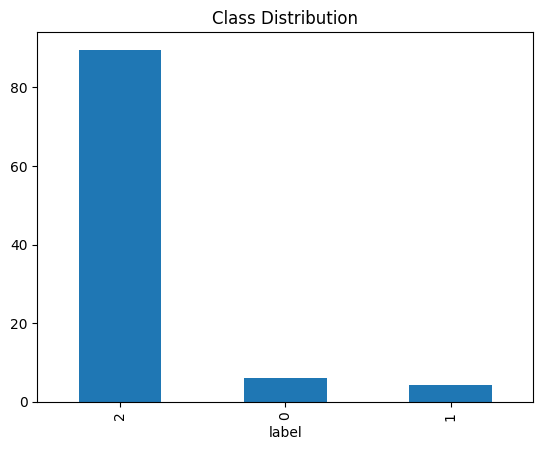

In [ ]:
val_df_label = val_df['label']
val_df_label.value_counts(normalize=True) * 100
val_df_label.plot(kind='bar')
plt.title("Class Distribution")
plt.show()

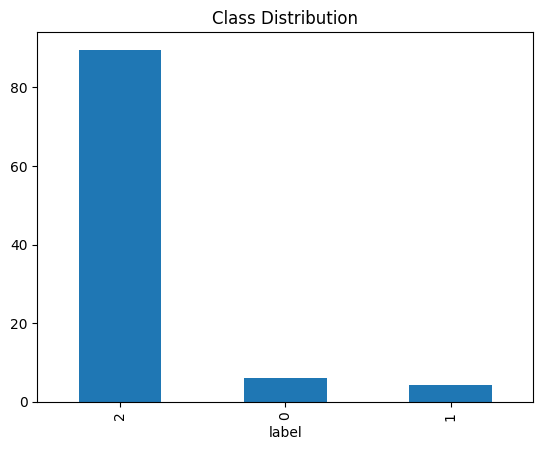

In [ ]:
test_df_label = test_df['label']
test_df_label.value_counts(normalize=True) * 100
test_df_label.plot(kind='bar')
plt.title("Class Distribution")
plt.show()

**Review** Length Statistics

In [3]:
train_df['Review_length'] = train_df['Review'].astype(str).apply(len)
train_df['Review_length'].describe()

,Review_length
count,110645.000000
mean,107.562655
std,102.967141
min,1.000000
25%,14.000000
50%,58.000000
75%,255.000000
max,255.000000


In [4]:
val_df['Review_length'] = val_df['Review'].astype(str).apply(len)
val_df['Review_length'].describe()

,Review_length
count,15806.000000
mean,108.180058
std,103.026011
min,1.000000
25%,14.000000
50%,59.000000
75%,255.000000
max,255.000000


In [5]:
test_df['Review_length'] = test_df['Review'].astype(str).apply(len)
test_df['Review_length'].describe()

,Review_length
count,31614.000000
mean,106.944740
std,102.847477
min,1.000000
25%,14.000000
50%,57.000000
75%,255.000000
max,255.000000


**Words** instead of characters

In [6]:
train_df['word_count'] = train_df['Review'].astype(str).apply(lambda x: len(x.split()))
train_df['word_count'].describe()

,word_count
count,110645.000000
mean,17.543766
std,16.581598
min,1.000000
25%,3.000000
50%,10.000000
75%,36.000000
max,64.000000


In [7]:
val_df['word_count'] = val_df['Review'].astype(str).apply(lambda x: len(x.split()))
val_df['word_count'].describe()

,word_count
count,15806.000000
mean,17.635392
std,16.569613
min,1.000000
25%,3.000000
50%,10.000000
75%,36.000000
max,59.000000


In [8]:
test_df['word_count'] = test_df['Review'].astype(str).apply(lambda x: len(x.split()))
test_df['word_count'].describe()

,word_count
count,31614.000000
mean,17.470678
std,16.590136
min,1.000000
25%,3.000000
50%,10.000000
75%,36.000000
max,58.000000


In [ ]:
# keeping only necessary columns
cols = ['Review', 'label']

train_df = train_df[cols].dropna()
val_df   = val_df[cols].dropna()
test_df  = test_df[cols].dropna()

Normalize **whitespace**

In [ ]:
def clean_whitespace(text):
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text


Lowercase **English** text only

In [ ]:
def conditional_lower(text):
    return ''.join([c.lower() if c.isascii() else c for c in text])

Convert **emojis** to text

In [ ]:
def demojize_text(text):
    return emoji.demojize(text)

In [ ]:
def preprocess_dataframe(df):
    df['Review'] = df['Review'].astype(str)
    df['Review'] = df['Review'].apply(clean_whitespace)
    df['Review'] = df['Review'].apply(conditional_lower)
    df['Review'] = df['Review'].apply(demojize_text)
    return df

In [ ]:
train_df = preprocess_dataframe(train_df)
val_df   = preprocess_dataframe(val_df)
test_df  = preprocess_dataframe(test_df)

Verify label **consistency**

In [ ]:
print("Train labels:\n", train_df['label'].value_counts())
print("Validation labels:\n", val_df['label'].value_counts())
print("Test labels:\n", test_df['label'].value_counts())

Train labels:
 label
2    99110
0     6772
1     4763
Name: count, dtype: int64
Validation labels:
 label
2    14159
0      967
1      680
Name: count, dtype: int64
Test labels:
 label
2    28318
0     1935
1     1361
Name: count, dtype: int64


**Tokenization** (XLM-RoBERTa)

In [ ]:
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=256
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenize_texts(train_df['Review'])
val_encodings   = tokenize_texts(val_df['Review'])
test_encodings  = tokenize_texts(test_df['Review'])

Final objects ready for **training**

In [ ]:
train_labels = train_df['label'].tolist()
val_labels   = val_df['label'].tolist()
test_labels  = test_df['label'].tolist()